# Обучение без учителя. Иерархическая кластеризация. DB-Scan 

## Подготовка

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')
from tqdm import TqdmWarning

In [32]:
# Настройка визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
# Загружаем данные напрямую с UCI (не требует регистрации на Kaggle)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 
    'other_debtors', 'residence', 'property', 'age', 'other_plans', 
    'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 
    'foreign_worker', 'credit_risk'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (1000, 21)


,checking_status,duration,credit_history,purpose,amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Часть 1. EDA

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   checking_status   1000 non-null   str  
 1   duration          1000 non-null   int64
 2   credit_history    1000 non-null   str  
 3   purpose           1000 non-null   str  
 4   amount            1000 non-null   int64
 5   savings           1000 non-null   str  
 6   employment        1000 non-null   str  
 7   installment_rate  1000 non-null   int64
 8   personal_status   1000 non-null   str  
 9   other_debtors     1000 non-null   str  
 10  residence         1000 non-null   int64
 11  property          1000 non-null   str  
 12  age               1000 non-null   int64
 13  other_plans       1000 non-null   str  
 14  housing           1000 non-null   str  
 15  existing_credits  1000 non-null   int64
 16  job               1000 non-null   str  
 17  people_liable     1000 n

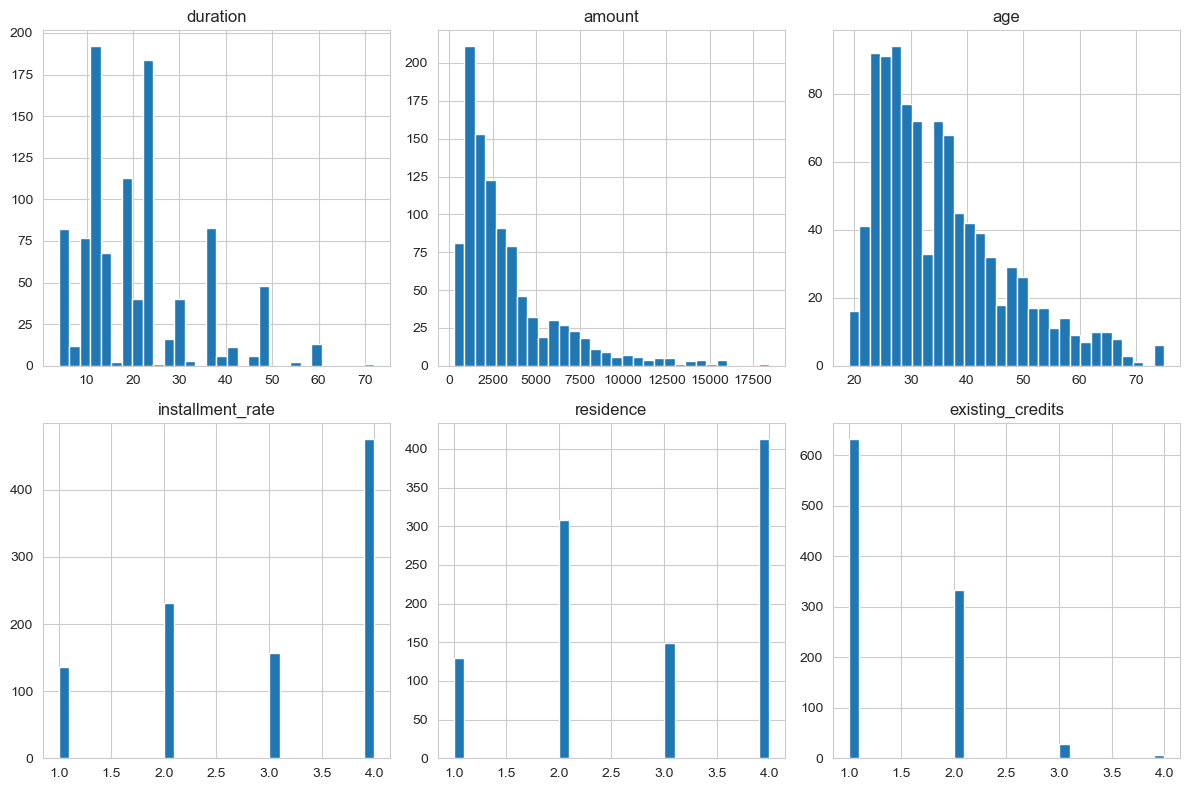

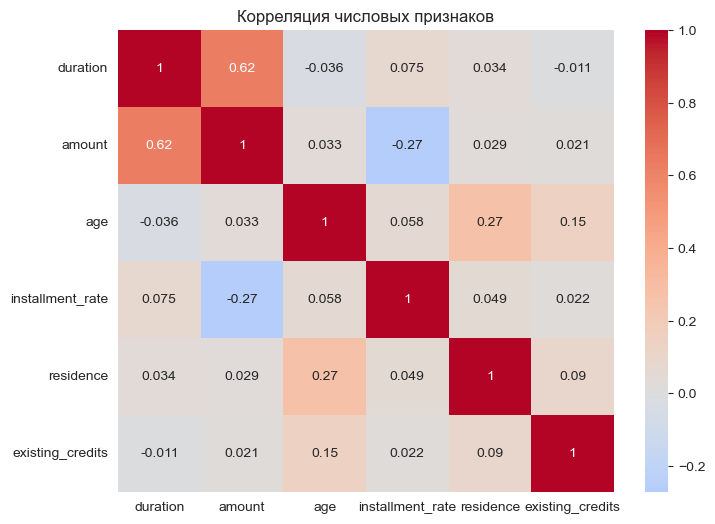

In [33]:
# Общая информация
print("Информация о данных:")
print(df.info())
print("Статистики числовых признаков:")
print(df.describe())

# Проверка пропусков
print("Пропущенные значения:")
print(df.isnull().sum())

# Распределение целевой переменной
print("Распределение кредитного риска:")
print(df['credit_risk'].value_counts())

# Визуализация числовых признаков
numeric_cols = ['duration', 'amount', 'age', 'installment_rate', 'residence', 'existing_credits']
df[numeric_cols].hist(bins=30, figsize=(12, 8), layout=(2, 3))
plt.tight_layout()
plt.show()

# Корреляционная матрица для числовых признаков
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

Выводы:

credit_risk:

- Хорошие кредиты: 700 клиентов (70%)
- Плохие кредиты: 300 клиентов (30%)
- Соотношение 70/30 — умеренный дисбаланс

Числовые признаки:

duration:

- Пики на 10-12 и 24 месяца
- Средний срок: 21 месяц (медиана 18)
- Разброс: от 4 до 72 месяцев
- Клиенты предпочитают краткосрочные (1 год) и среднесрочные (2 года) кредиты

amount:

- Сильно скошено вправо (right-skewed)
- Среднее: 3,271, медиана: 2,319
- Большинство кредитов: < 5,000
- Максимум: 18,424 (выбросы)
- Преобладают небольшие потребительские кредиты

age
- Скошено вправо
- Средний возраст: 35.5 лет (медиана 33)
- Основная масса: 20-40 лет
- Диапазон: 19-75 лет
- Большинство клиентов — молодые и среднего возраста

### Преобразование категориальных признаков в числовые

In [35]:
# Копируем датафрейм для предобработки
df_processed = df.copy()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'credit_risk' in categorical_cols:
    categorical_cols.remove('credit_risk')

print(f"Категориальные признаки для кодирования: {categorical_cols}")

# Label Encoding для категориальных признаков
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df[col])
    label_encoders[col] = le

if 'credit_risk' in df_processed.columns:
    df_processed['credit_risk'] = df_processed['credit_risk'].map({1: 0, 2: 1})
    print("credit_risk преобразован")

Категориальные признаки для кодирования: ['checking_status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_plans', 'housing', 'job', 'telephone', 'foreign_worker']
credit_risk преобразован


### Масштабирование данных

Приведение данных к одному масштабу при кластеризации необходимо потому что алгоритмы кластеризации опираются на вычисление расстояний между объектами и разный масштаб признаков искажает эти расстояния

In [36]:
# Признаки для кластеризации
features = [col for col in df_processed.columns if col != 'credit_risk']
X = df_processed[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Пример после масштабирования:\n{X_scaled[:3]}")

Пример после масштабирования:
[[-1.25456565 -1.23647786  1.34401408  0.26406793 -0.74513141  1.83316907
   1.33807849  0.91847717  0.44932648 -0.30368573  1.04698668 -1.29372298
   2.76645648  0.46083068  0.13371046  1.02707891  0.14694918 -0.42828957
   1.21459768 -0.19601428]
 [-0.45902624  2.24819436 -0.50342796  0.26406793  0.94981679 -0.69970702
  -0.31795924 -0.87018333 -0.96364986 -0.30368573 -0.76597727 -1.29372298
  -1.19140394  0.46083068  0.13371046 -0.704926    0.14694918 -0.42828957
  -0.82331789 -0.19601428]
 [ 1.13205258 -0.73866754  1.34401408  1.35978547 -0.41656241 -0.69970702
   0.51005962 -0.87018333  0.44932648 -0.30368573  0.14050471 -1.29372298
   1.18331231  0.46083068  0.13371046 -0.704926   -1.38377145  2.33486893
  -0.82331789 -0.19601428]]


## Часть 2: Моделирование кластеризации

### Функции для оценки качества кластеризации

In [37]:
def plot_elbow_silhouette(X, model_name, model_func, k_range):
    """Построение Elbow и Silhouette plot для подбора k"""
    inertias = []
    silhouettes = []
    
    for k in k_range:
        if model_name == 'DBSCAN':
            model = model_func(eps=k/100)
            labels = model.fit_predict(X)
            # Для DBSCAN: считаем силуэт только для не-шумовых точек
            mask = labels != -1
            if mask.sum() > 1 and len(set(labels[mask])) > 1:
                sil = silhouette_score(X[mask], labels[mask])
                silhouettes.append(sil)
            else:
                silhouettes.append(0)
            inertias.append(len(labels[labels == -1]))  # количество шумовых точек
        else:
            # Исправлено: передаем k как позиционный аргумент или через **kwargs
            try:
                model = model_func(n_clusters=k)
            except TypeError:
                # Если функция не принимает n_clusters, пробуем просто k
                model = model_func(k)
            
            labels = model.fit_predict(X)
            inertias.append(model.inertia_ if hasattr(model, 'inertia_') else 0)
            if len(set(labels)) > 1:
                silhouettes.append(silhouette_score(X, labels))
            else:
                silhouettes.append(0)
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(k_range, inertias, 'bo-')
    axes[0].set_xlabel('Количество кластеров' if model_name != 'DBSCAN' else 'eps')
    axes[0].set_ylabel('Inertia / Шумовые точки')
    axes[0].set_title(f'{model_name}: Elbow Method')
    axes[0].grid(True)
    
    axes[1].plot(k_range, silhouettes, 'ro-')
    axes[1].set_xlabel('Количество кластеров' if model_name != 'DBSCAN' else 'eps')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'{model_name}: Silhouette Analysis')
    axes[1].axhline(y=0, color='gray', linestyle='--')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Возвращаем оптимальное k по силуэту
    best_idx = np.argmax(silhouettes)
    return k_range[best_idx], silhouettes[best_idx]

### K-Means кластеризация

K-Means кластеризация


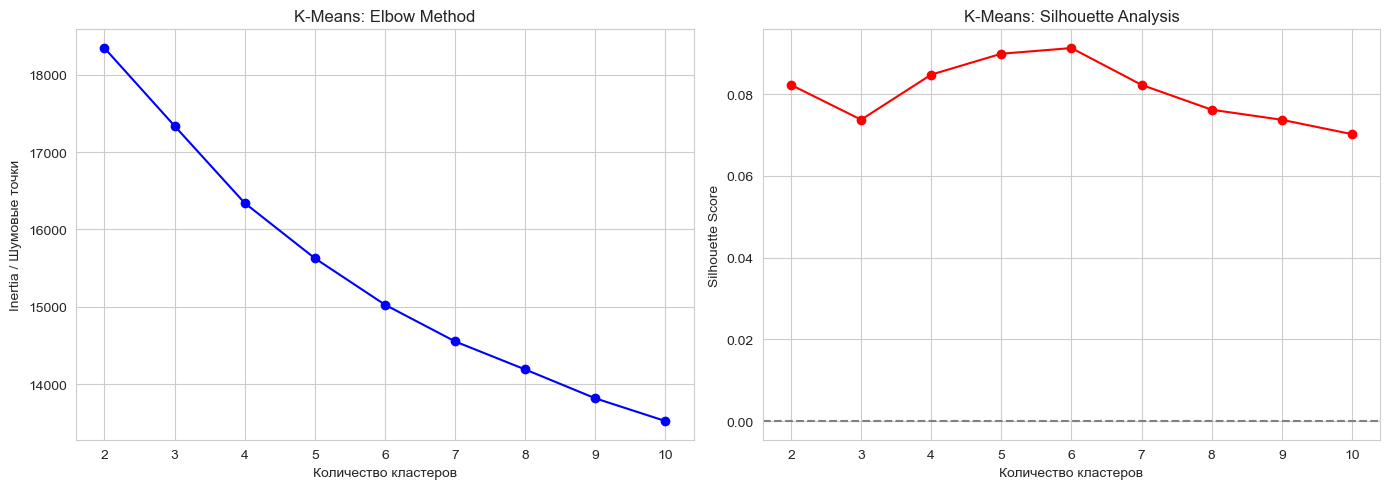

Оптимальное количество кластеров для K-Means: 6 (Silhouette: 0.091)


In [50]:
print("K-Means кластеризация")

# Подбор оптимального k
k_range = range(2, 11)
best_k_kmeans, best_sil_kmeans = plot_elbow_silhouette(
    X_scaled, 
    'K-Means', 
    lambda n_clusters: KMeans(n_clusters=n_clusters, random_state=42, n_init=10), 
    k_range
)

print(f"Оптимальное количество кластеров для K-Means: {best_k_kmeans} (Silhouette: {best_sil_kmeans:.3f})")

# Финальная кластеризация
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
df_processed['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

### Иерархическая кластеризация

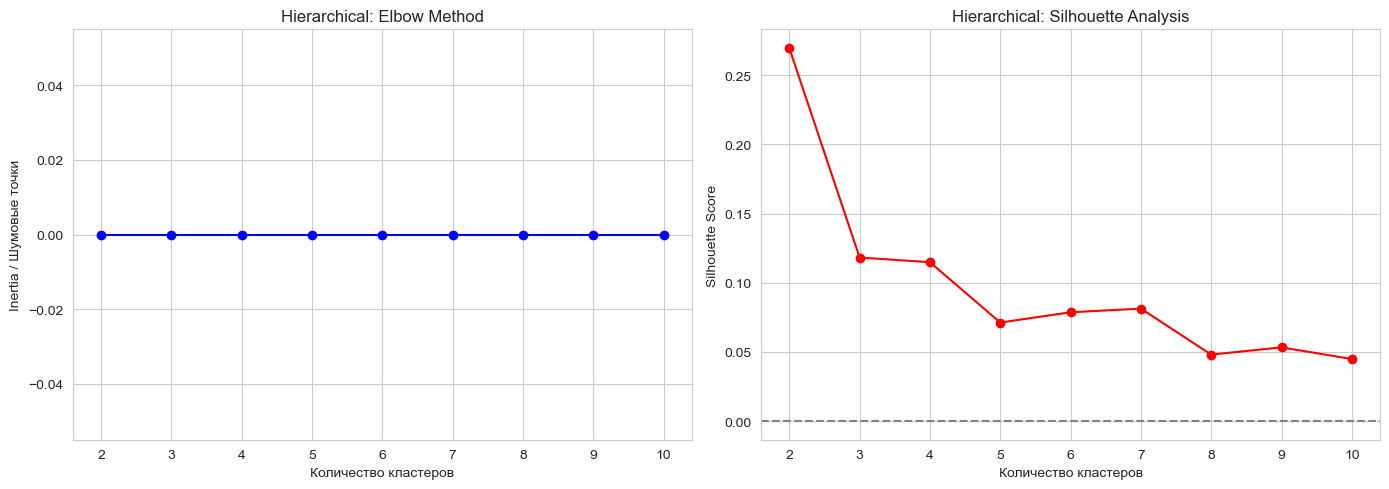

Оптимальное количество кластеров для Hierarchical: 2 (Silhouette: 0.270)


In [41]:
# Подбор оптимального k
best_k_hier, best_sil_hier = plot_elbow_silhouette(
    X_scaled, 
    'Hierarchical',
    lambda n_clusters: AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
    k_range
)

print(f"Оптимальное количество кластеров для Hierarchical: {best_k_hier} (Silhouette: {best_sil_hier:.3f})")

# Финальная кластеризация
hier = AgglomerativeClustering(n_clusters=best_k_hier, linkage='ward')
df_processed['hier_cluster'] = hier.fit_predict(X_scaled)

### DBSCAN кластеризация

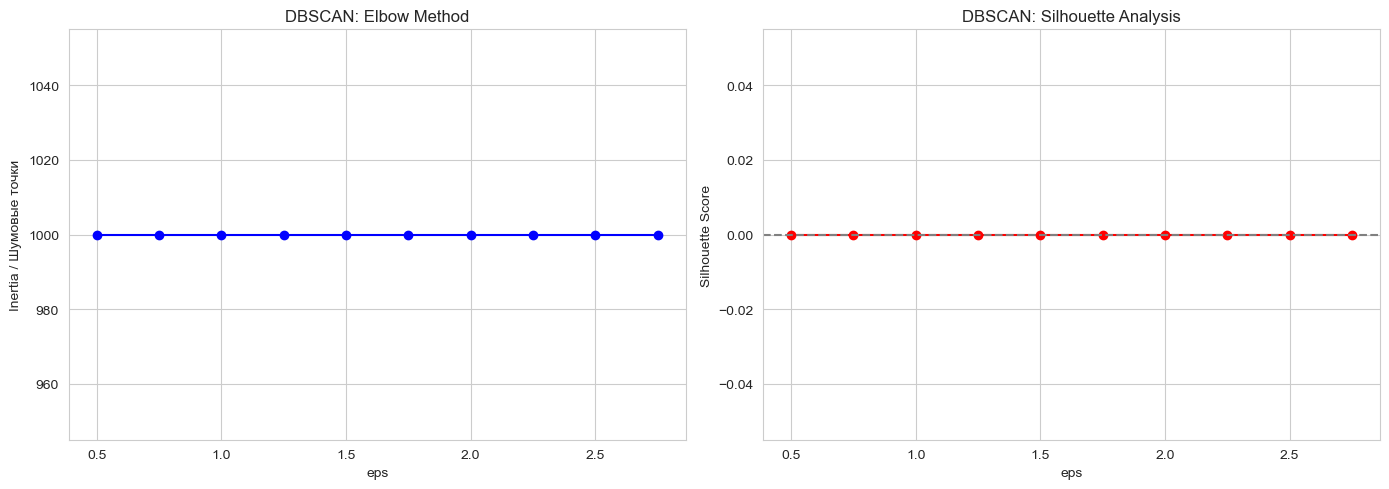

Оптимальный eps для DBSCAN: 0.50 (Silhouette: 0.000)
Распределение по кластерам DBSCAN:
dbscan_cluster
-1    1000
Name: count, dtype: int64
Шумовые точки (метка -1): 1000


In [43]:
# Для DBSCAN подбираем eps вместо k
eps_range = np.arange(0.5, 3.0, 0.25)
best_eps_dbscan, best_sil_dbscan = plot_elbow_silhouette(
    X_scaled, 
    'DBSCAN', 
    lambda eps: DBSCAN(eps=eps, min_samples=5),
    eps_range
)

print(f"Оптимальный eps для DBSCAN: {best_eps_dbscan:.2f} (Silhouette: {best_sil_dbscan:.3f})")

# Финальная кластеризация
dbscan = DBSCAN(eps=best_eps_dbscan, min_samples=5)
df_processed['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Статистика по кластерам
print(f"Распределение по кластерам DBSCAN:")
print(df_processed['dbscan_cluster'].value_counts().sort_index())
print(f"Шумовые точки (метка -1): {(df_processed['dbscan_cluster'] == -1).sum()}")

### Визуализация с уменьшением размерности (PCA, t-SNE, UMAP)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


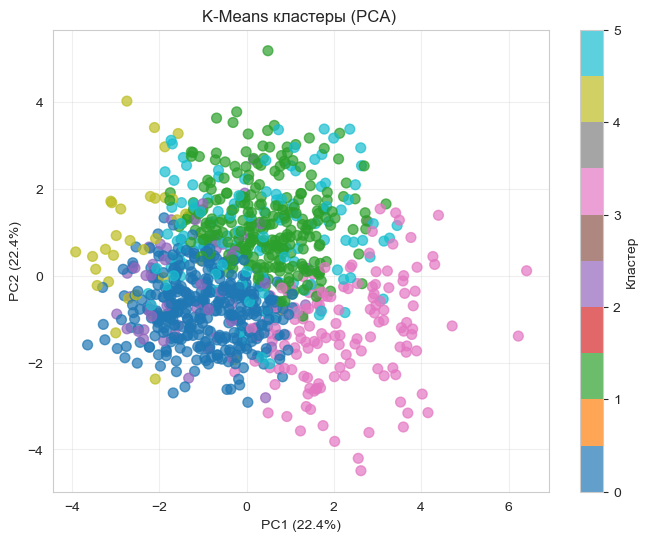

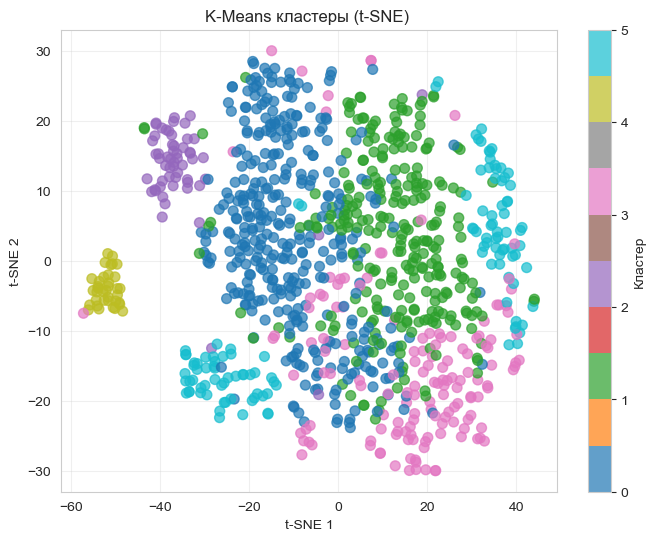

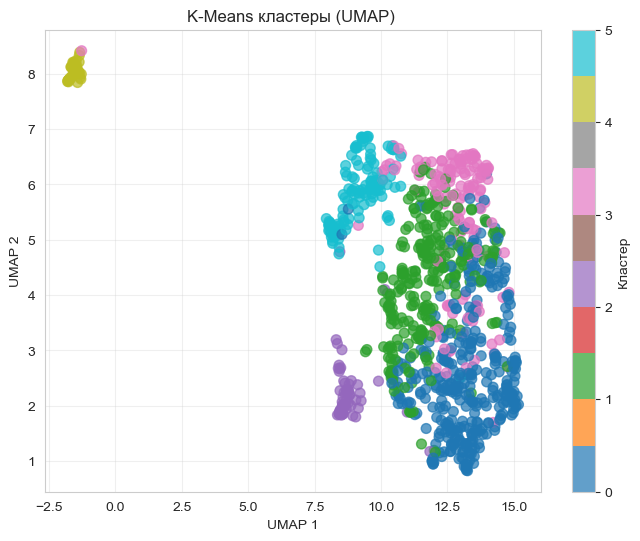

In [44]:
def plot_clusters_2d(X, labels, method_name, reduction_method, title_suffix=""):
    """Визуализация кластеров в 2D после уменьшения размерности"""
    
    # Применяем метод уменьшения размерности
    if reduction_method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X)
        explained_var = reducer.explained_variance_ratio_.sum()
        xlabel = f'PC1 ({explained_var*100:.1f}%)'
        ylabel = f'PC2 ({explained_var*100:.1f}%)'
        
    elif reduction_method == 't-SNE':
        # Исправлено: n_iter → max_iter
        reducer = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
        X_2d = reducer.fit_transform(X)
        xlabel, ylabel = 't-SNE 1', 't-SNE 2'
        
    elif reduction_method == 'UMAP':
        reducer = umap.UMAP(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X)
        xlabel, ylabel = 'UMAP 1', 'UMAP 2'
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=50, alpha=0.7)
    plt.colorbar(scatter, label='Кластер')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'{method_name} кластеры ({reduction_method}) {title_suffix}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Визуализируем K-Means кластеры с разными методами
for reduction in ['PCA', 't-SNE', 'UMAP']:
    plot_clusters_2d(X_scaled, df_processed['kmeans_cluster'], 'K-Means', reduction)

## Часть 3: Интерпретация кластеров

### Расчёт средних значений признаков по кластерам

Анализ кластеров: kmeans_cluster
Средние значения числовых признаков по кластерам:
                duration   amount  installment_rate    age
kmeans_cluster                                            
0                  17.83  2234.71              2.88  28.53
1                  18.35  2357.77              3.37  43.13
2                  19.40  2618.93              2.91  34.77
3                  37.31  8283.56              2.63  36.48
4                  11.42  2109.94              2.50  35.28
5                  19.57  3035.69              2.94  38.82


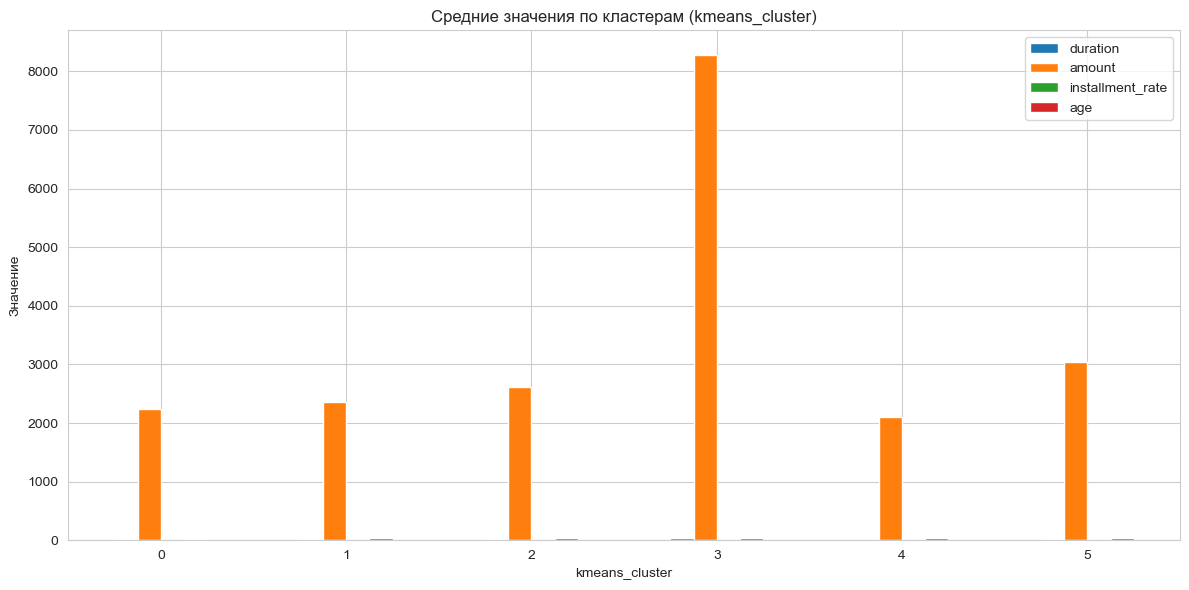

Топ-3 категории для ключевых признаков в каждом кластере:
checking_status:
  Кластер 0: {'A11': np.float64(33.2), 'A12': np.float64(29.3), 'A14': np.float64(29.3)}
  Кластер 1: {'A14': np.float64(62.2), 'A12': np.float64(16.4), 'A11': np.float64(13.5)}
  Кластер 2: {'A12': np.float64(42.1), 'A11': np.float64(40.4), 'A14': np.float64(14.0)}
  Кластер 3: {'A12': np.float64(42.9), 'A14': np.float64(29.9), 'A11': np.float64(27.2)}
  Кластер 4: {'A11': np.float64(41.7), 'A14': np.float64(36.1), 'A12': np.float64(11.1)}
  Кластер 5: {'A14': np.float64(42.5), 'A11': np.float64(31.7), 'A12': np.float64(21.7)}
credit_history:
  Кластер 0: {'A32': np.float64(71.2), 'A34': np.float64(10.4), 'A33': np.float64(6.8)}
  Кластер 1: {'A34': np.float64(54.9), 'A32': np.float64(35.3), 'A33': np.float64(8.4)}
  Кластер 2: {'A32': np.float64(66.7), 'A34': np.float64(22.8), 'A31': np.float64(7.0)}
  Кластер 3: {'A32': np.float64(44.2), 'A34': np.float64(25.2), 'A33': np.float64(16.3)}
  Кластер 4: {'A32': n

In [46]:
def analyze_clusters(df, cluster_col, feature_cols, original_df):
    """Анализ кластеров: средние значения и интерпретация"""
    
    print(f"Анализ кластеров: {cluster_col}")
    
    # Средние значения для числовых признаков
    numeric_features = [f for f in feature_cols if f in ['duration', 'amount', 'age', 'installment_rate']]
    
    if numeric_features:
        print("Средние значения числовых признаков по кластерам:")
        summary = df.groupby(cluster_col)[numeric_features].mean().round(2)
        print(summary)
        
        # Визуализация
        summary.plot(kind='bar', figsize=(12, 6), rot=0)
        plt.title(f'Средние значения по кластерам ({cluster_col})')
        plt.ylabel('Значение')
        plt.tight_layout()
        plt.show()
    
    # Для категориальных признаков: доля категорий в каждом кластере
    categorical_features = [f for f in feature_cols if f not in numeric_features]
    
    if categorical_features:
        print(f"Топ-3 категории для ключевых признаков в каждом кластере:")
        key_cat_features = ['checking_status', 'credit_history', 'purpose', 'job']
        key_cat_features = [f for f in key_cat_features if f in categorical_features]
        
        for feat in key_cat_features:
            print(f"{feat}:")
            cross_tab = pd.crosstab(df[cluster_col], original_df[feat])
            # Нормируем по строкам (по кластерам)
            cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
            # Показываем топ-3 категории для каждого кластера
            for cluster in sorted(df[cluster_col].unique()):
                if cluster in cross_tab_norm.index:
                    top_cats = cross_tab_norm.loc[cluster].nlargest(3)
                    print(f"  Кластер {cluster}: {dict(top_cats.round(1))}")

# Анализируем K-Means кластеры
analyze_clusters(df_processed, 'kmeans_cluster', df_processed.columns.tolist(), df)

### Boxplot для визуализации различий между кластерами

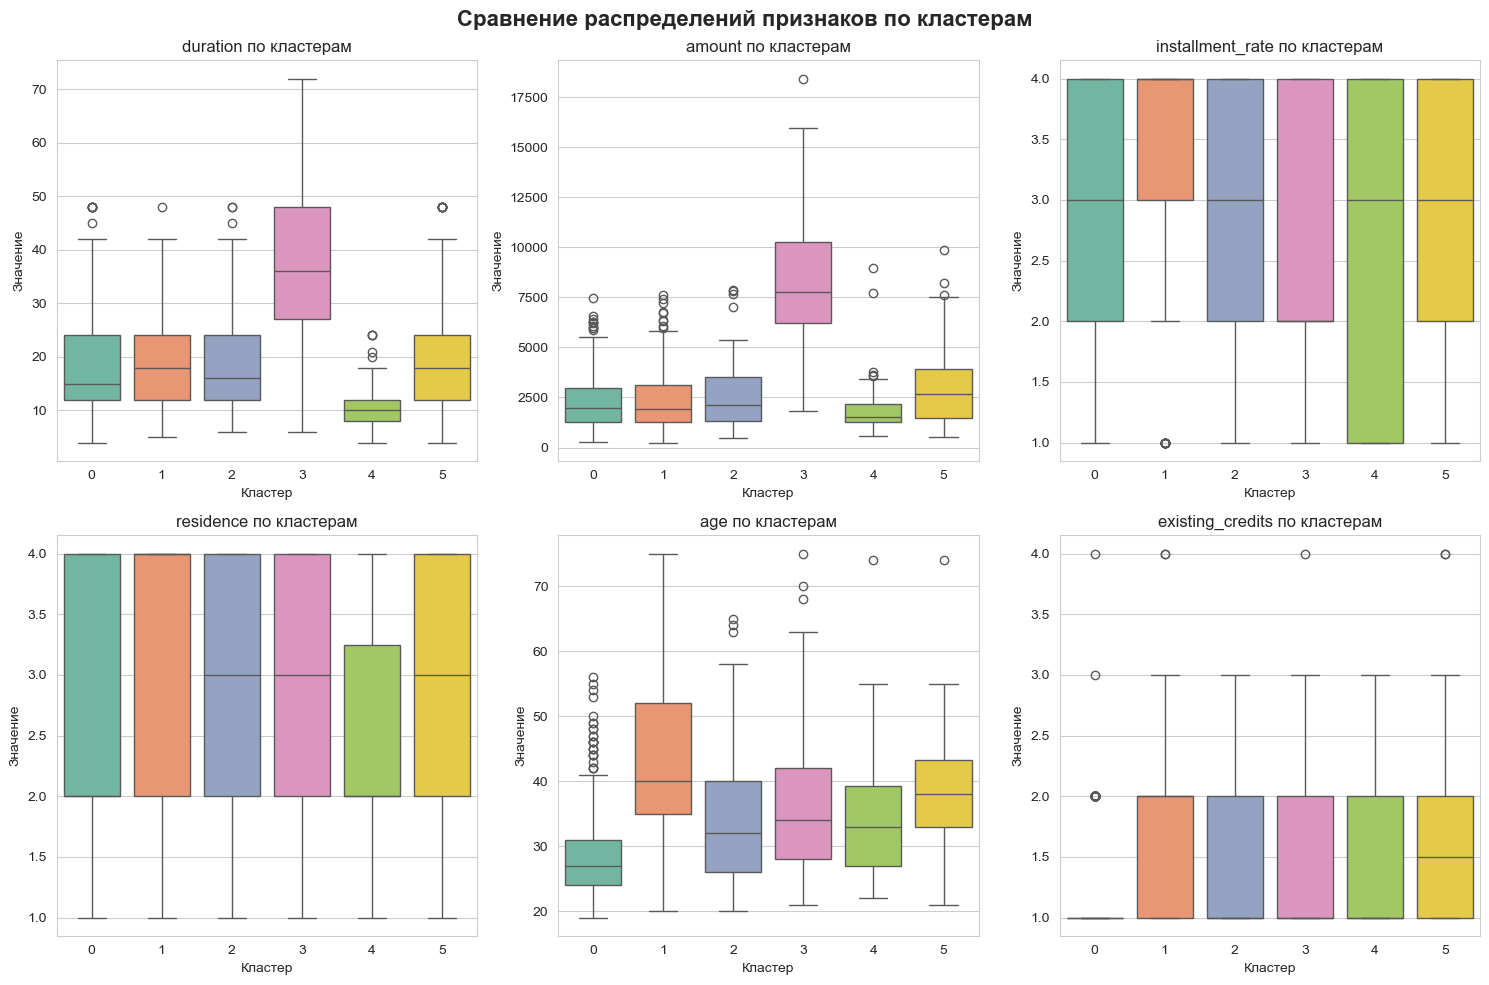

In [29]:
def plot_boxplots_by_cluster(df, cluster_col, feature_cols, original_features):
    """Boxplot для каждого признака, сгруппированный по кластерам"""
    
    numeric_features = [f for f in feature_cols if f in ['duration', 'amount', 'age', 'installment_rate', 'residence', 'existing_credits']]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, feat in enumerate(numeric_features[:6]):
        if idx < len(axes):
            # Восстанавливаем оригинальные названия для отображения
            display_name = original_features.get(feat, feat)
            df_temp = df[[cluster_col, feat]].copy()
            
            sns.boxplot(x=cluster_col, y=feat, data=df_temp, ax=axes[idx], palette='Set2')
            axes[idx].set_title(f'{feat} по кластерам')
            axes[idx].set_xlabel('Кластер')
            axes[idx].set_ylabel('Значение')
            axes[idx].tick_params(axis='x', rotation=0)
    
    # Скрываем пустые подграфики
    for idx in range(len(numeric_features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Сравнение распределений признаков по кластерам', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Создаём словарь для красивых названий признаков
feature_names = {
    'duration': 'Срок кредита (мес)',
    'amount': 'Сумма кредита',
    'age': 'Возраст',
    'installment_rate': 'Ставка платежа (%)',
    'residence': 'Время проживания',
    'existing_credits': 'Число кредитов'
}

plot_boxplots_by_cluster(df_processed, 'kmeans_cluster', df_processed.columns.tolist(), feature_names)

### Интерпретация результатов

In [48]:
clusters_summary = df_processed.groupby('kmeans_cluster')[['amount', 'age', 'duration']].agg(['mean', 'median', 'std'])
print("Сводная статистика по кластерам:")
print(clusters_summary.round(1))

print("Связь кластеров с кредитным риском:")
risk_by_cluster = pd.crosstab(df_processed['kmeans_cluster'], df['credit_risk'], 
                               normalize='index') * 100
print(risk_by_cluster.round(1))
print("Доля плохих кредитов по кластерам:")
print(risk_by_cluster[1].sort_values(ascending=False))

Сводная статистика по кластерам:
                amount                   age              duration         \
                  mean  median     std  mean median   std     mean median   
kmeans_cluster                                                              
0               2234.7  1961.0  1312.1  28.5   27.0   6.8     17.8   15.0   
1               2357.8  1935.0  1478.0  43.1   40.0  12.0     18.3   18.0   
2               2618.9  2101.0  1854.9  34.8   32.0  11.0     19.4   16.0   
3               8283.6  7758.0  3293.4  36.5   34.0  11.6     37.3   36.0   
4               2109.9  1520.0  1744.4  35.3   33.0  10.4     11.4   10.0   
5               3035.7  2672.0  1961.1  38.8   38.0   7.8     19.6   18.0   

                      
                 std  
kmeans_cluster        
0                9.0  
1                8.3  
2               11.3  
3               12.9  
4                5.4  
5               11.6  
Связь кластеров с кредитным риском:
credit_risk        1     2
kme

## Выводы:

- Чем выше должность, тем больше сумма и длиннее срок
- Чем моложе клиент, тем более бытовая цель кредита
- Отсутствие счета в банке - короткие кредиты
- Пожилые клиенты гасят долги быстрее

### amount — главный разделяющий признак

Кластер 3 сильнее всего отличается от всех:

- Медиана: ~7,500-8,000
- Разброс: до 15,000+
- Много выбросов
- Кластер 4: самая низкая медиана (~1,500-2,000)
- Кластеры 0,1,2,5: похожи, медианы ~2,000-2,500

Интерпритации:

Кластер 3 = Крупные заемщики (бизнес, дорогие покупки)

Кластер 4 = Мелкие заемщики (небольшие потребности, низкий доход)

Остальные = Средний класс

### duration (срок кредита) — второй по важности

Кластер 3:

- Медиана: ~35-40 месяцев
- Самый большой разброс (до 70+ месяцев)

Кластер 4:

- Медиана: ~10 месяцев (самая низкая)
- Узкий разброс

Кластеры 0,1,2,5:

Медианы: 15-20 месяцев

Интерпретация:

Кластер 3: Долгосрочные кредиты (крупные суммы требуют долгого погашения)

Кластер 4: Краткосрочные кредиты(быстрое погашение, низкий риск)

Остальные: Среднесрочные кредиты

### age — третий по важности

Кластер 0:

- Медиана: ~27-28 лет (самая низкая)
- Узкий диапазон (19-40 лет)

Кластер 1:

- Медиана: ~40 лет (самая высокая)
- Огромный разброс (20-75 лет)

Кластеры 2,3,4,5:

Медианы: 33-38 лет

Интерпретация:

Кластер 0: Молодые клиенты (карьерный старт, первые кредиты)

Кластер 1: Зрелые клиенты (разный возраст, но в среднем старше)

Остальные = Средний возраст

### installment_rate, residence, existing_credits — не информативны

- Все boxplot'ы выглядят одинаково для всех кластеров
- Это дискретные признаки (значения 1, 2, 3, 4)
- Медианы и разброс совпадают

## Интерпретация кластеров на основе boxplot'ов

### Кластер 0: Молодежь

- Сумма: Средняя
- Срок: Средний
- Возраст: Самый молодой (27-28)

### Кластер 1: Зрелые

- Сумма: Средняя
- Срок: Средний
- Возраст: Самый старший (40+), большой разброс

### Кластеры 2: Средний класс

- Все признаки около среднего
- Массовый сегмент банка

### Кластер 3: Богатые

- Сумма: В 3-4 раза выше остальных
- Срок: В 2 раза длиннее
- Возраст: Средний (35-40)

### Кластер 4: Бюджетный

- Сумма: Самая низкая
- Срок: Самый короткий (10 мес)
- Возраст: Средний

### Кластер 5: Средний класс

- Все признаки около среднего
- Массовый сегмент банка
